In [1]:
from pyspark.sql import SparkSession

spark = (
        SparkSession.builder
        .appName("fintek_analytics")
        .master("spark://spark-master:7077")

        .config("spark.executor.memory", "2g")
        .config("spark.driver.memory", "1g")
        .config("spark.executor.cores", 2)
        .config("spark.sql.shuffle.partitions", 10)

        .config("spark.driver.host", "fintek-jupyter")
        .config("spark.driver.bindAddress", "0.0.0.0")

        .config("spark.jars.packages", "org.postgresql:postgresql:42.7.3")

        .getOrCreate()
    )

:: loading settings :: url = jar:file:/opt/conda/lib/python3.11/site-packages/pyspark/jars/ivy-2.5.3.jar!/org/apache/ivy/core/settings/ivysettings.xml
Ivy Default Cache set to: /home/jovyan/.ivy2.5.2/cache
The jars for the packages stored in: /home/jovyan/.ivy2.5.2/jars
org.postgresql#postgresql added as a dependency
:: resolving dependencies :: org.apache.spark#spark-submit-parent-66c90158-edc8-4314-9b5a-0d43e1da2ef8;1.0
	confs: [default]
	found org.postgresql#postgresql;42.7.3 in central
	found org.checkerframework#checker-qual;3.42.0 in central
:: resolution report :: resolve 63ms :: artifacts dl 2ms
	:: modules in use:
	org.checkerframework#checker-qual;3.42.0 from central in [default]
	org.postgresql#postgresql;42.7.3 from central in [default]
	---------------------------------------------------------------------
	|                  |            modules            ||   artifacts   |
	|       conf       | number| search|dwnlded|evicted|| number|dwnlded|
	---------------------------

In [2]:
jdbc_url = "jdbc:postgresql://fintek-postgres:5432/fintek_db"

properties = {
    "user": "finance",
    "password": "finance123",
    "driver": "org.postgresql.Driver"
}

try:
    print("Veriler veritabanından okunuyor...")
    
    sql_prices = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            p.price_time,
            p.close,
            a.asset_type
        FROM prices p
        JOIN assets a
            ON p.asset_id = a.asset_id
        WHERE p.price_time >= '2024-01-01'
    ) AS index_prices
    """,
    properties=properties
)

    sql_returns = spark.read.jdbc(
    url=jdbc_url,
    table="""
    (   SELECT
            a.ticker,
            r.return_time,
            r.log_return,
            a.asset_type
        FROM returns r
        JOIN assets a
            ON r.asset_id = a.asset_id
        WHERE r.return_time >= '2024-01-01'
    ) AS index_returns
    """,
    properties=properties
)
    print("\n--- Prices ---")
    sql_prices.show(5)

    print("\n--- Returns ---")
    sql_returns.show(5)

except Exception as e:
    print(f"Veritabanına bağlanırken bir hata oluştu: {e}")

Veriler veritabanından okunuyor...

--- Prices ---
+------+----------+------------------+----------+
|ticker|price_time|             close|asset_type|
+------+----------+------------------+----------+
|  AAPL|2024-01-02|183.73130798339844|    equity|
|  MSFT|2024-01-02|364.58941650390625|    equity|
|  NVDA|2024-01-02|48.138572692871094|    equity|
|  AMZN|2024-01-02|149.92999267578125|    equity|
| GOOGL|2024-01-02|137.03741455078125|    equity|
+------+----------+------------------+----------+
only showing top 5 rows

--- Returns ---
+------+-----------+--------------------+----------+
|ticker|return_time|          log_return|asset_type|
+------+-----------+--------------------+----------+
|  AAPL| 2024-01-02|-0.03644279815750...|    equity|
|  MSFT| 2024-01-02|-0.01384411882653...|    equity|
|  NVDA| 2024-01-02|-0.02772218214267...|    equity|
|  AMZN| 2024-01-02|-0.01331725248741...|    equity|
| GOOGL| 2024-01-02|-0.01094085152441...|    equity|
+------+-----------+--------------

In [3]:
import pandas as pd
import numpy as np

print("🚀 Spark verileri Pandas formatına dönüştürülüyor...")

df_prices = sql_prices.toPandas()
df_returns = sql_returns.toPandas()

print("Veriler ayrıştırılıyor ve Pivot tablolara dönüştürülüyor...")

df_prices['price_time'] = pd.to_datetime(df_prices['price_time'])
df_returns['return_time'] = pd.to_datetime(df_returns['return_time'])

df_prices_indices = df_prices[df_prices['asset_type'] == 'index'].copy()
df_prices_stocks = df_prices[df_prices['asset_type'] == 'equity'].copy()

df_returns_indices = df_returns[df_returns['asset_type'] == 'index'].copy()
df_returns_stocks = df_returns[df_returns['asset_type'] == 'equity'].copy()

prices_index_pivot = df_prices_indices.pivot(
    index='price_time', columns='ticker', values='close'
).sort_index()

prices_stock_pivot = df_prices_stocks.pivot(
    index='price_time', columns='ticker', values='close'
).sort_index()

returns_index_pivot = df_returns_indices.pivot(
    index='return_time', columns='ticker', values='log_return'
).sort_index()

returns_stock_pivot = df_returns_stocks.pivot(
    index='return_time', columns='ticker', values='log_return'
).sort_index()


prices_index_pivot.columns.name = None
prices_stock_pivot.columns.name = None
returns_index_pivot.columns.name = None
returns_stock_pivot.columns.name = None

prices_index_pivot.index.name = None
prices_stock_pivot.index.name = None
returns_index_pivot.index.name = None
returns_stock_pivot.index.name = None



print("\n--- ENDEKS GETİRİLERİ (PİVOT - Saf Sayısal) ---")
print(returns_index_pivot.head())

print("\n--- HİSSE GETİRİLERİ (PİVOT - Saf Sayısal) ---")
print(returns_stock_pivot.head())

🚀 Spark verileri Pandas formatına dönüştürülüyor...
Veriler ayrıştırılıyor ve Pivot tablolara dönüştürülüyor...

--- ENDEKS GETİRİLERİ (PİVOT - Saf Sayısal) ---
                 DJI    NASDAQ     SP500
2024-01-02  0.000676 -0.016483 -0.005677
2024-01-03 -0.007581 -0.011835 -0.008049
2024-01-04  0.000271 -0.005629 -0.003434
2024-01-05  0.000688  0.000949  0.001824
2024-01-08  0.005773  0.021773  0.014016

--- HİSSE GETİRİLERİ (PİVOT - Saf Sayısal) ---
                AAPL      AMZN       BAC     GOOGL        GS       JPM  \
2024-01-02 -0.036443 -0.013317  0.006808 -0.010941  0.006537  0.011573   
2024-01-03 -0.007516 -0.009786 -0.010974  0.005413 -0.016907 -0.004368   
2024-01-04 -0.012781 -0.026619  0.008020 -0.018380  0.003034  0.006614   
2024-01-05 -0.004021  0.004624  0.018467 -0.004851  0.009072  0.005005   
2024-01-08  0.023887  0.026230 -0.007873  0.022655  0.006243 -0.001452   

                MSFT      NVDA  
2024-01-02 -0.013844 -0.027722  
2024-01-03 -0.000728 -0.012514  
2

Korelasyon matrisleri hesaplanıyor ve haritalar çiziliyor...



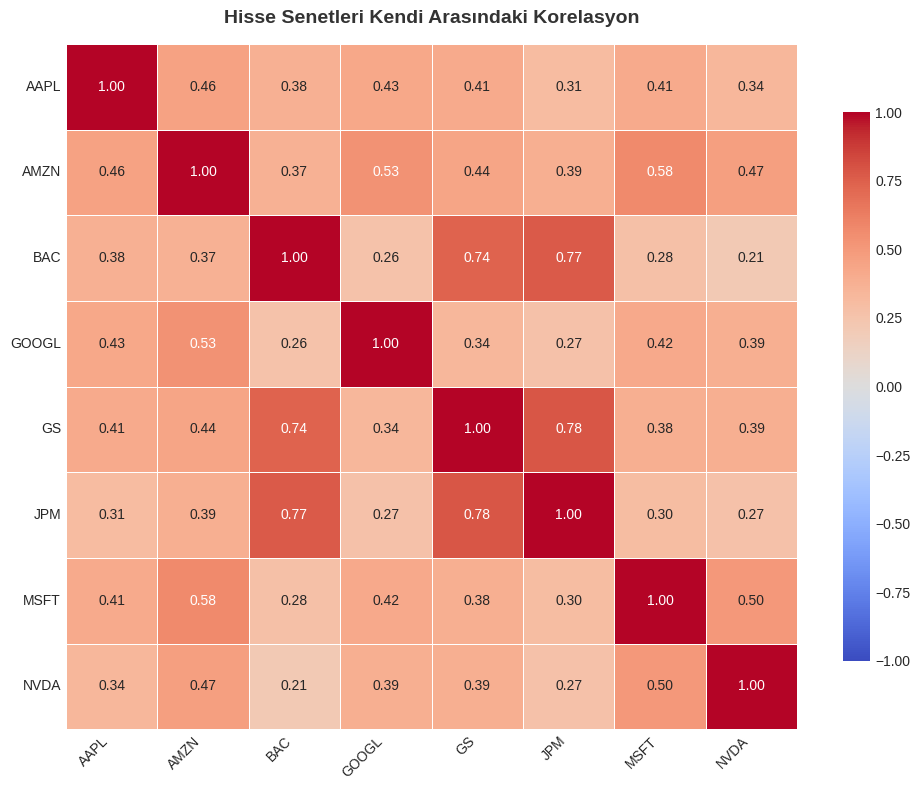

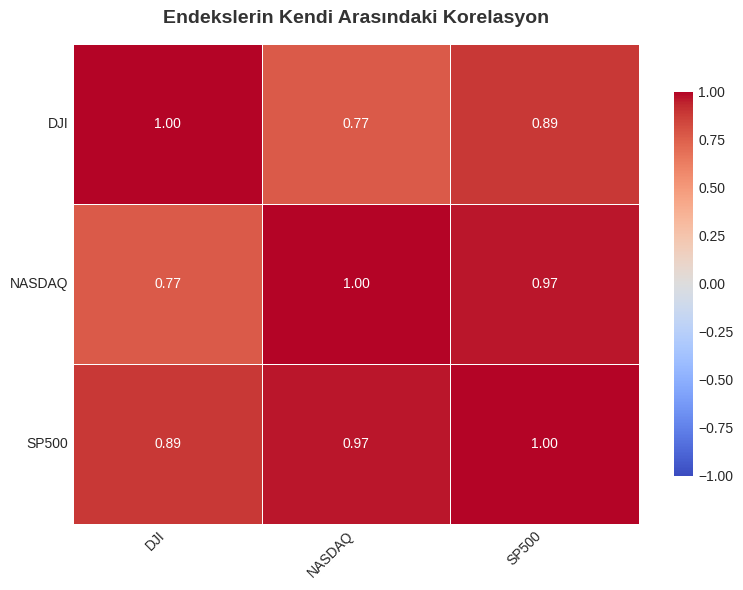

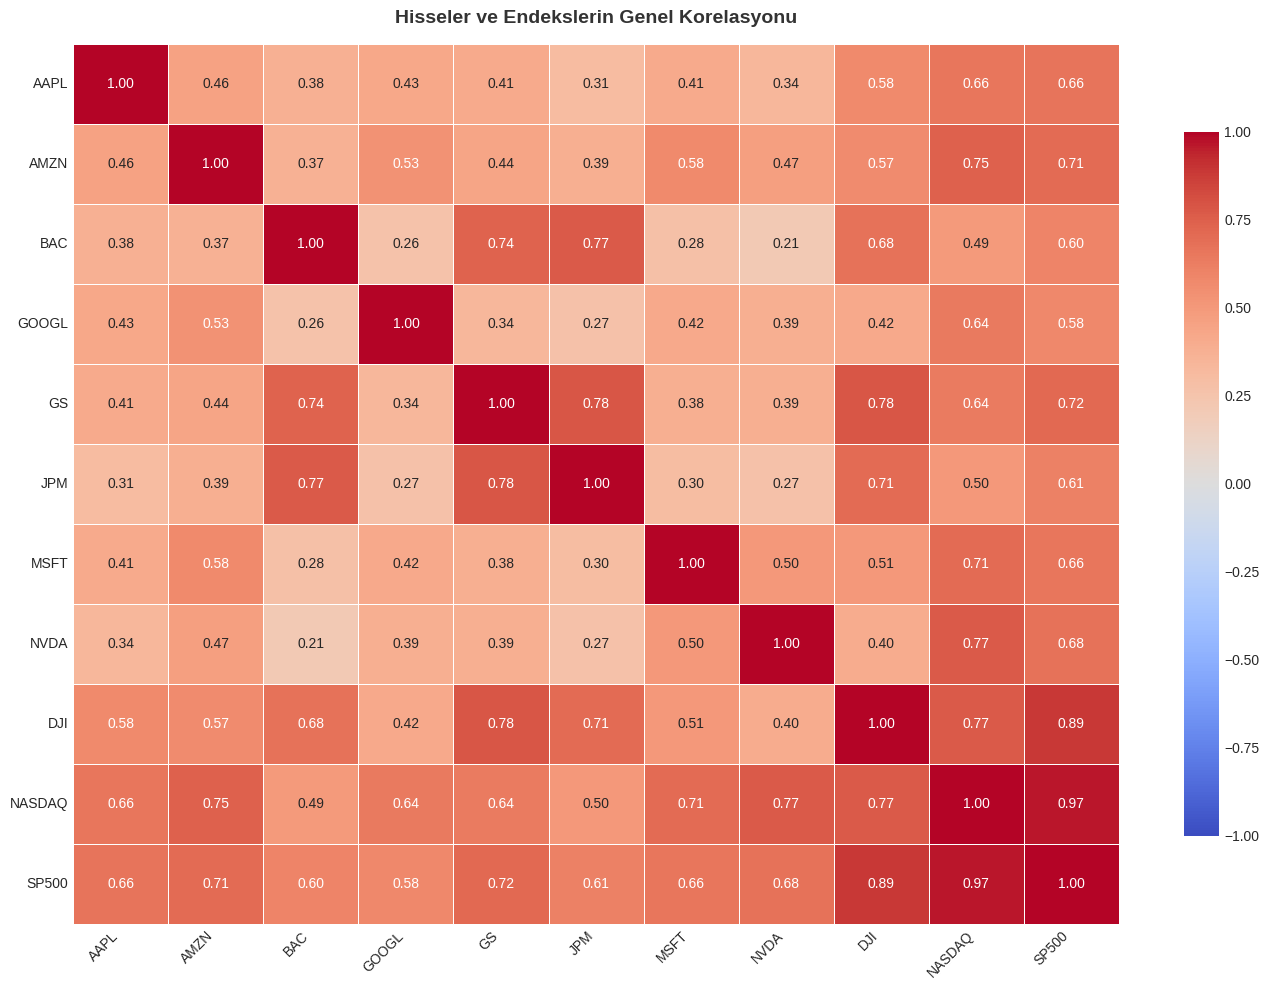

In [92]:
import os
import sys

sys.path.append(os.path.abspath('..')) 
from src.plotting import plot_correlation_heatmap

print("Korelasyon matrisleri hesaplanıyor ve haritalar çiziliyor...\n")

plot_correlation_heatmap(returns_stock_pivot, 
                         "Hisse Senetleri Kendi Arasındaki Korelasyon")

plot_correlation_heatmap(returns_index_pivot, 
                         "Endekslerin Kendi Arasındaki Korelasyon", 
                         figsize=(8, 6))


returns_combined = pd.merge(
    returns_stock_pivot, 
    returns_index_pivot, 
    left_index=True,  
    right_index=True, 
    how='inner'
)

plot_correlation_heatmap(returns_combined, 
                         "Hisseler ve Endekslerin Genel Korelasyonu", 
                         time_col='return_time', 
                         figsize=(14, 10))

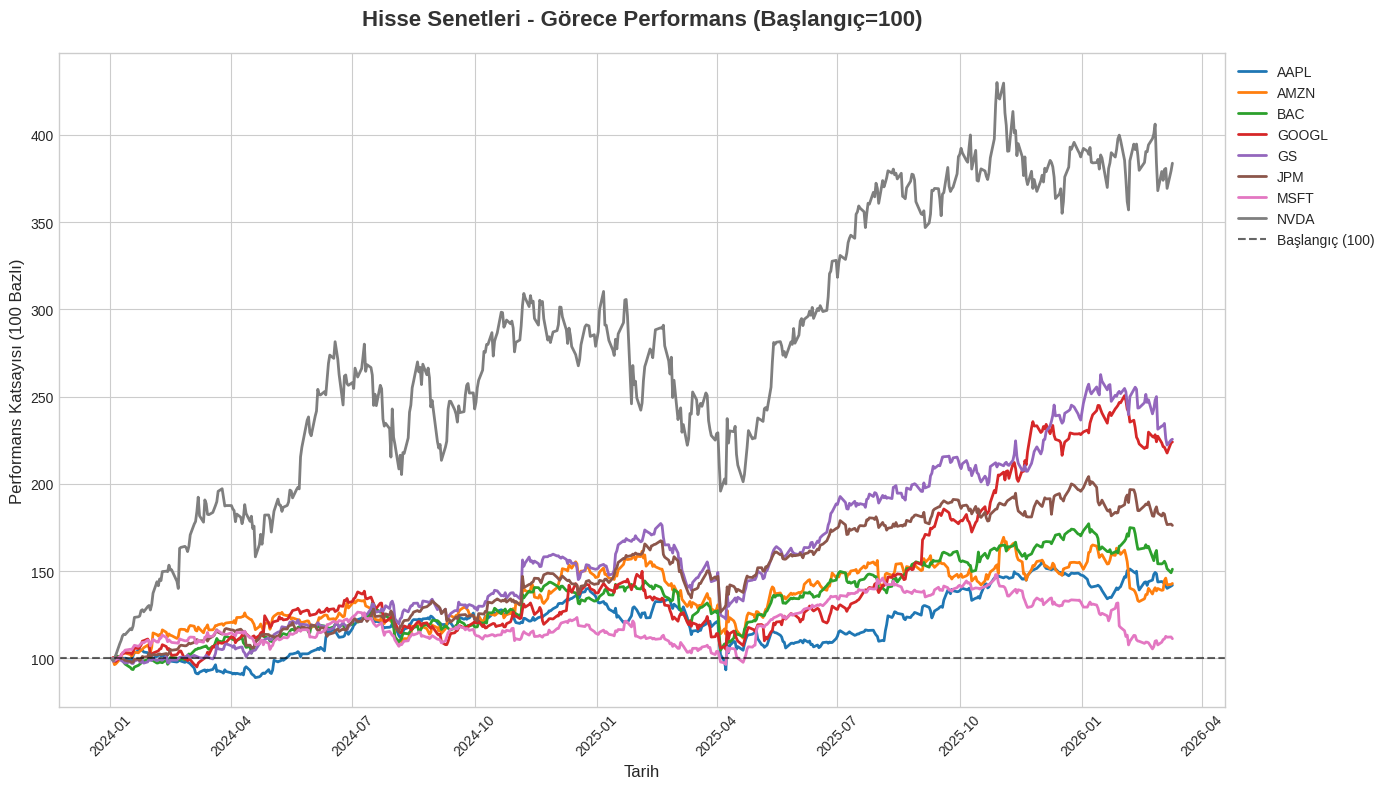

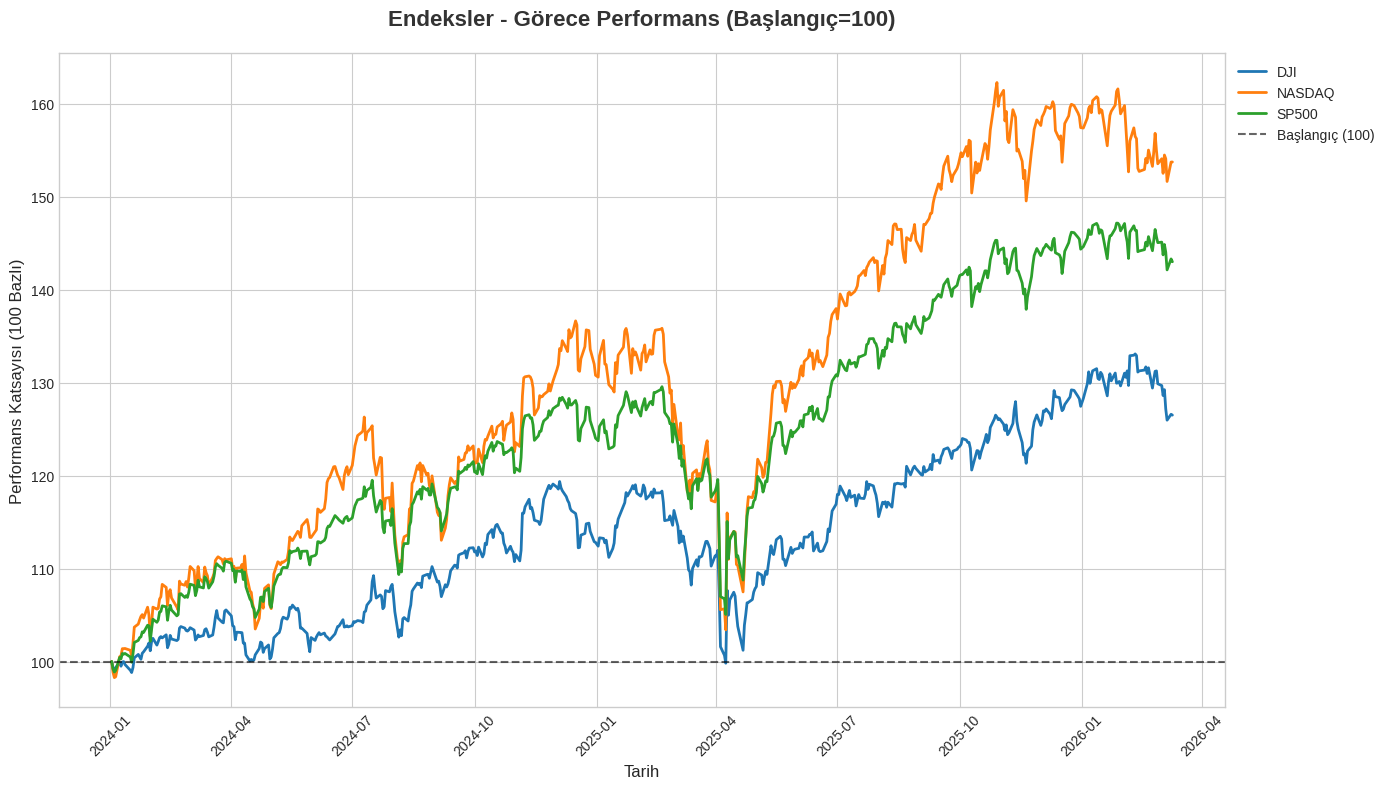

In [143]:
import os
import sys

sys.path.append(os.path.abspath('..')) 
from src.plotting import plot_normalized_performance

plot_normalized_performance(prices_stock_pivot, "Hisse Senetleri")

plot_normalized_performance(prices_index_pivot, "Endeksler")

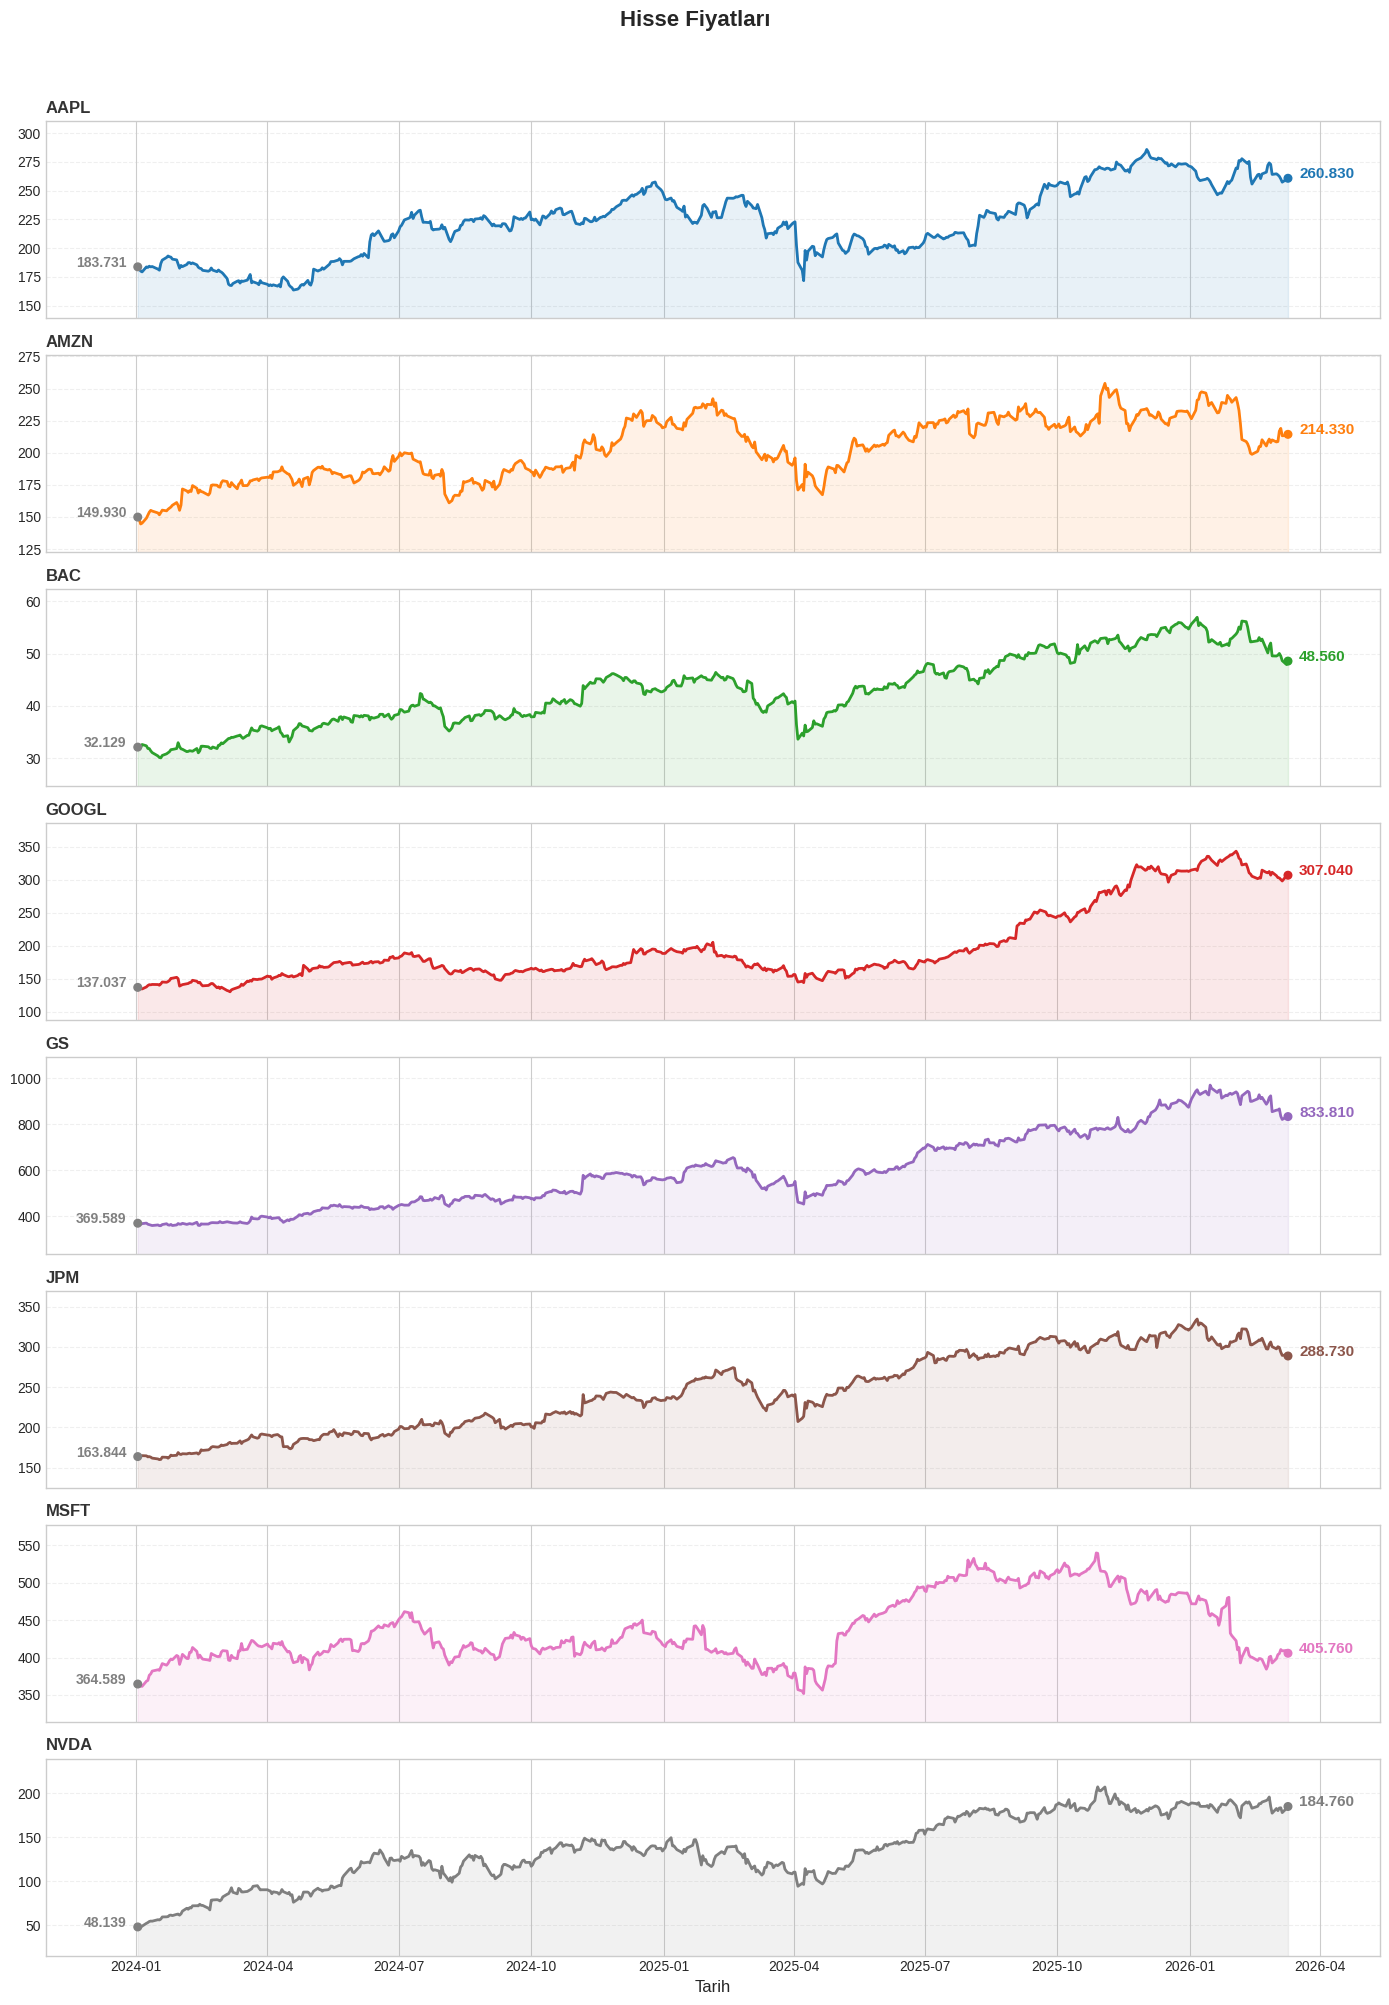

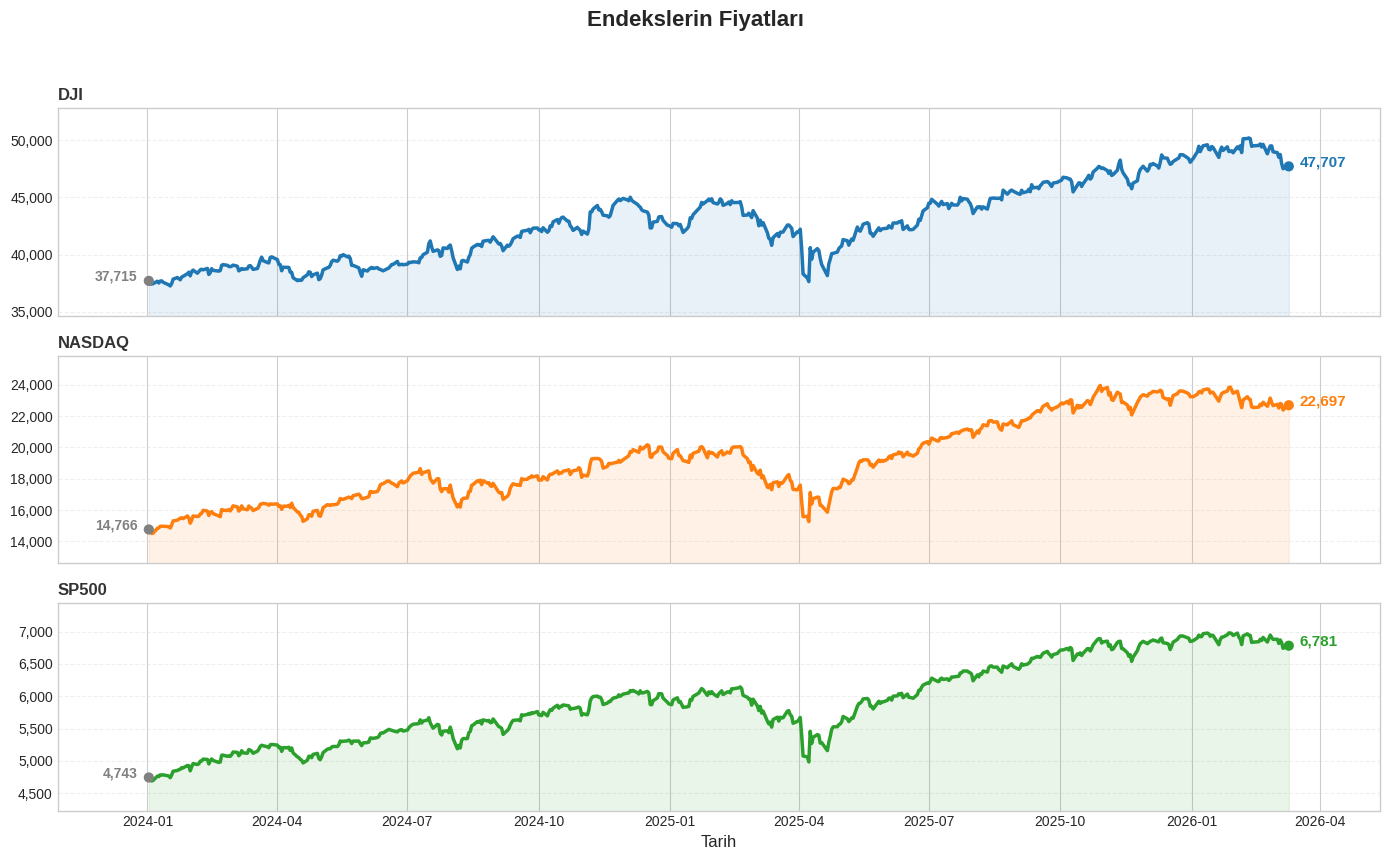

In [145]:
import os
import sys

sys.path.append(os.path.abspath('..')) 
from src.plotting import plot_time_series_subplots

plot_time_series_subplots(prices_stock_pivot, "Hisse Fiyatları", format_type='stock')

plot_time_series_subplots(prices_index_pivot, "Endekslerin Fiyatları", format_type='index')

In [159]:
%load_ext autoreload
%autoreload 2
import os
import sys

sys.path.append(os.path.abspath('..')) 
from src.sum_perf import sum_perf_report

prices_combined = pd.concat([prices_stock_pivot, prices_index_pivot], axis=1)
returns_combined = pd.concat([returns_stock_pivot, returns_index_pivot], axis=1)

sum_perf_report(prices_index_pivot, returns_index_pivot, caption="Endeks Analizi")

sum_perf_report(prices_stock_pivot, returns_stock_pivot, caption="Hisse Senetleri Analizi")

sum_perf_report(prices_combined, returns_combined)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,Ticker,Son Fiyat,Toplam Getiri (%),Günlük Ort. Getiri (%),Sharpe Oranı,Risk Değeri (Günlük %),Yıllık Volatilite (%),VaR (%10),VaR (%5),Maks. Düşüş (%)
1,DJI,"47,706.51$",+26.49%,+0.043%,0.77,0.89%,14.15%,0.95%,1.33%,-16.37%
2,NASDAQ,"22,697.10$",+53.71%,+0.075%,0.91,1.32%,20.92%,1.48%,2.18%,-24.32%
3,SP500,"6,781.48$",+42.98%,+0.064%,1.04,0.98%,15.62%,0.95%,1.56%,-18.90%


,Ticker,Son Fiyat,Toplam Getiri (%),Günlük Ort. Getiri (%),Sharpe Oranı,Risk Değeri (Günlük %),Yıllık Volatilite (%),VaR (%10),VaR (%5),Maks. Düşüş (%)
1,AAPL,260.83$,+41.96%,+0.057%,0.52,1.74%,27.64%,1.84%,2.75%,-33.36%
2,AMZN,214.33$,+42.95%,+0.063%,0.50,1.97%,31.33%,2.19%,2.89%,-30.88%
3,BAC,48.56$,+51.14%,+0.077%,0.77,1.58%,25.14%,1.53%,2.30%,-27.51%
4,GOOGL,307.04$,+124.06%,+0.145%,1.24,1.86%,29.56%,1.86%,2.61%,-29.81%
5,GS,833.81$,+125.60%,+0.150%,1.29,1.84%,29.18%,1.79%,2.48%,-30.90%
6,JPM,288.73$,+76.22%,+0.106%,1.09,1.54%,24.42%,1.41%,2.29%,-24.42%
7,MSFT,405.76$,+11.29%,+0.017%,0.18,1.49%,23.68%,1.56%,2.39%,-28.78%
8,NVDA,184.76$,+283.81%,+0.240%,1.21,3.14%,49.91%,3.30%,4.58%,-36.88%


,Ticker,Son Fiyat,Toplam Getiri (%),Günlük Ort. Getiri (%),Sharpe Oranı,Risk Değeri (Günlük %),Yıllık Volatilite (%),VaR (%10),VaR (%5),Maks. Düşüş (%)
1,AAPL,260.83$,+41.96%,+0.057%,0.52,1.74%,27.64%,1.84%,2.75%,-33.36%
2,AMZN,214.33$,+42.95%,+0.063%,0.50,1.97%,31.33%,2.19%,2.89%,-30.88%
3,BAC,48.56$,+51.14%,+0.077%,0.77,1.58%,25.14%,1.53%,2.30%,-27.51%
4,GOOGL,307.04$,+124.06%,+0.145%,1.24,1.86%,29.56%,1.86%,2.61%,-29.81%
5,GS,833.81$,+125.60%,+0.150%,1.29,1.84%,29.18%,1.79%,2.48%,-30.90%
6,JPM,288.73$,+76.22%,+0.106%,1.09,1.54%,24.42%,1.41%,2.29%,-24.42%
7,MSFT,405.76$,+11.29%,+0.017%,0.18,1.49%,23.68%,1.56%,2.39%,-28.78%
8,NVDA,184.76$,+283.81%,+0.240%,1.21,3.14%,49.91%,3.30%,4.58%,-36.88%
9,DJI,"47,706.51$",+26.49%,+0.043%,0.77,0.89%,14.15%,0.95%,1.33%,-16.37%
10,NASDAQ,"22,697.10$",+53.71%,+0.075%,0.91,1.32%,20.92%,1.48%,2.18%,-24.32%


In [ ]:
spark.stop()